In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

if "../" not in sys.path:
    sys.path.append("../")

In [3]:
import src.controllers.clothoids as clothoids

In [4]:
import gymnasium_driving
import gymnasium_driving.wrappers
import src.helpers as helpers

objc[434]: Class SDLApplication is implemented in both /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1450f4890) and /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x146c612c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[434]: Class SDLAppDelegate is implemented in both /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1450f48e0) and /Users/nadir/Documents/research-project/code/experimentations/gymnasium/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x146c61318). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[434]: Class SDLTranslatorRe

In [5]:
environment = gymnasium_driving.environment.CarEnvironment(
    render_mode="rgb_array",
    road_network=gymnasium_driving.components.roads.RoadNetwork(
        roads=[
            gymnasium_driving.components.roads.create_rectangular_track(
                center=(50, 50),
                length=100,
                height=100,
                turn_radius=8.0,
                width=8.0,
            ),
            # gymnasium_driving.components.roads.Road(
            #     segments=[
            #         gymnasium_driving.components.roads.StraightSegment(
            #             start=(0, 0),
            #             heading=0.0,  # pointing right
            #             length=100,
            #         )
            #     ]
            # )
        ],
    ),
    # proportion=(0.90, 0.0),
    proportion=(0.90, 0.00),
)

environment = gymnasium_driving.wrappers.observations.WithBaseInfo(environment)
environment = gymnasium_driving.wrappers.observations.WithObstaclesInfo(environment)
environment = gymnasium_driving.wrappers.observations.WithPathInfo(environment)

In [6]:
import src
import src.environments.straight
import src.environments.cristal

In [8]:
environment = src.environments.cristal.make_environment(
    discrete=False,
    render_mode="rgb_array",
    with_base_position=True,
)

environment = gymnasium_driving.wrappers.observations.WithBaseInfo(environment)
environment = gymnasium_driving.wrappers.observations.WithObstaclesInfo(environment)
environment = gymnasium_driving.wrappers.observations.WithPathInfo(environment)

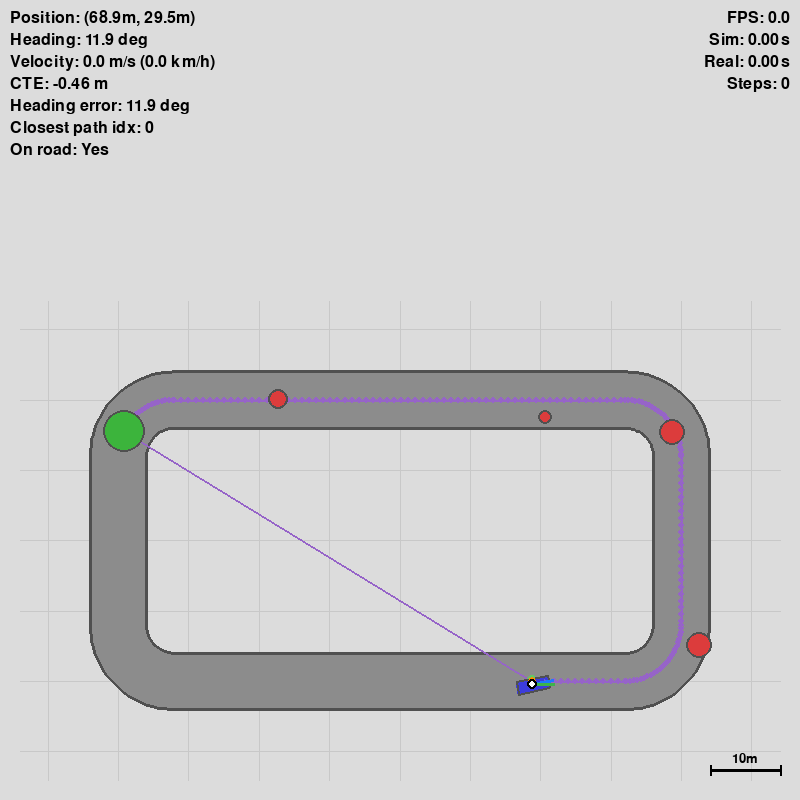

In [10]:
environment.reset()
helpers.preview(environment)

In [12]:
controller = clothoids.ClothoidTentaclesController(
    environment=environment,
    num_tentacles=41,
    t0=10.0,
    l0=10.0,
    min_tentacle_length=10.0,  # Ensure reasonable tentacle length at low speeds
    num_points_per_tentacle=64,

    # clearance, curvature, trajectory
    weights=(0.1, 0.2, 0.5),

    target_velocity=3.5,
)

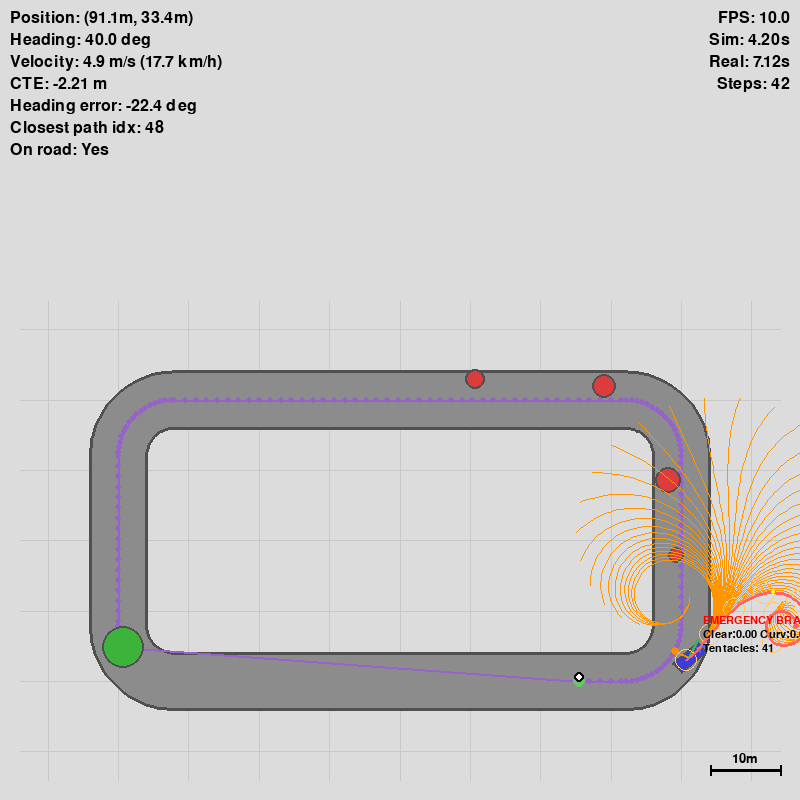

In [15]:
# controller = purepursuit.PurePursuitController()

observation, info = environment.reset()

for i in range(500):
    # TODO: what are the _states ?
    action, _states = controller.get_action(observation=observation)
    
    print(action)
    
    observation, reward, terminated, truncated, info = environment.step(action)
    
    environment.unwrapped.overlay_manager.clear()
    controller.draw_debug(observation=observation, path=environment.unwrapped.path)
    
    helpers.preview(environment)

    if terminated or truncated:
        break

environment.close()